# Online Retail II — Customer Segmentation

This case study builds a customer-segmentation workflow from more than one million raw retail transaction lines.

The main challenge is not simply applying a clustering algorithm. The raw dataset is recorded at **invoice-line grain**, while the analytical objective is to segment **customers**. The workflow therefore moves through:

\begin{equation}
\text{transaction lines}
\rightarrow
\text{clean purchases}
\rightarrow
\text{customer-level features}
\rightarrow
\text{customer segments}
\end{equation}

The project covers transaction-quality auditing, customer-level feature engineering, feature transformation, K-Means, cluster stability, DBSCAN, Gaussian Mixture Models, post-hoc geographic profiling, and anomaly detection.

## Dataset

The project uses **Online Retail II** from the UCI Machine Learning Repository, covering transactions from December 2009 through December 2011.

The raw fields include invoice number, product code, description, quantity, timestamp, unit price, customer identifier, and country.

The dataset is downloaded automatically from UCI. The raw workbook is not stored in this repository.

## 1. Imports

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
    silhouette_samples
)
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

RANDOM_STATE = 42

## 2. Data acquisition

In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

UCI_ZIP_URL = (
    "https://archive.ics.uci.edu/static/public/502/"
    "online%2Bretail%2Bii.zip"
)

zip_path = DATA_DIR / "online_retail_ii.zip"
xlsx_path = DATA_DIR / "online_retail_II.xlsx"

# Download only when the dataset is not already available locally.
if not xlsx_path.exists():
    if not zip_path.exists():
        print("Downloading Online Retail II from UCI...")
        urlretrieve(UCI_ZIP_URL, zip_path)

    with zipfile.ZipFile(zip_path) as zf:
        xlsx_members = [
            name
            for name in zf.namelist()
            if name.lower().endswith(".xlsx")
        ]

        if not xlsx_members:
            raise FileNotFoundError(
                "No .xlsx file was found inside the UCI archive."
            )

        member = xlsx_members[0]
        zf.extract(member, DATA_DIR)

        extracted_path = DATA_DIR / member
        if extracted_path != xlsx_path:
            extracted_path.replace(xlsx_path)

# The official workbook contains one sheet for each yearly period.
sheet_names = [
    "Year 2009-2010",
    "Year 2010-2011",
]

sheets = pd.read_excel(
    xlsx_path,
    sheet_name=sheet_names,
)

df = pd.concat(
    sheets.values(),
    ignore_index=True,
)

# Normalize the historical column names used in the workbook.
df = df.rename(
    columns={
        "Invoice": "InvoiceNo",
        "Price": "UnitPrice",
        "Customer ID": "CustomerID",
    }
)

print(df.shape)
df.head()

(1067371, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Data-quality audit

The raw data is first inspected for missing identifiers, duplicate-looking rows, cancellations, non-positive quantities, non-positive prices, temporal coverage, and customer/invoice counts.

Exact duplicate-looking rows are **not automatically removed**. The source contains no unique invoice-line identifier, so two identical rows cannot be proven to represent an ingestion duplicate rather than two legitimate repeated lines. Removing them would therefore impose an unsupported assumption and could alter customer-level revenue or item counts.

In [3]:
# Ensure InvoiceDate has the correct type
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

print("Shape:")
print(df.shape)

print("\nDtypes:")
print(df.dtypes)

print("\nMissing values:")
print(
    pd.DataFrame({
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100
    }).sort_values("missing", ascending=False)
)

print("\nExact duplicates:")
print(df.duplicated().sum())

print("\nUnique invoices:")
print(df["InvoiceNo"].nunique(dropna=True))

print("\nUnique customers:")
print(df["CustomerID"].nunique(dropna=True))

print("\nDate range:")
print("Min:", df["InvoiceDate"].min())
print("Max:", df["InvoiceDate"].max())

print("\nCountries:")
print("Number of countries:", df["Country"].nunique(dropna=True))
print(df["Country"].value_counts(dropna=False))

print("\nQuantity:")
print(df["Quantity"].describe())
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

print("\nUnitPrice:")
print(df["UnitPrice"].describe())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

Shape:
(1067371, 8)

Dtypes:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
             missing  missing_pct
CustomerID    243007    22.766873
Description     4382     0.410541
StockCode          0     0.000000
InvoiceNo          0     0.000000
Quantity           0     0.000000
InvoiceDate        0     0.000000
UnitPrice          0     0.000000
Country            0     0.000000

Exact duplicates:
34335

Unique invoices:
53628

Unique customers:
5942

Date range:
Min: 2009-12-01 07:45:00
Max: 2011-12-09 12:50:00

Countries:
Number of countries: 43
Country
United Kingdom          981330
EIRE                     17866
Germany                  17624
France                   14330
Netherlands               5140
Spain                     3811
Switzerland               31

In [4]:
print("Negative Quantity:")
display(
    df.loc[df["Quantity"] < 0]
      .head(20)
)

print("\nZero Quantity:")
display(
    df.loc[df["Quantity"] == 0]
      .head(20)
)

print("\nNegative UnitPrice:")
display(
    df.loc[df["UnitPrice"] < 0]
      .head(20)
)

print("\nZero UnitPrice:")
display(
    df.loc[df["UnitPrice"] == 0]
      .head(20)
)

print("\nInvoice prefixes:")
print(df["InvoiceNo"].astype(str).str[0].value_counts())

Negative Quantity:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom



Zero Quantity:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country



Negative UnitPrice:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom



Zero UnitPrice:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom



Invoice prefixes:
InvoiceNo
5    939382
4    108489
C     19494
A         6
Name: count, dtype: int64


### Customer-linked transactions and cancellations

Rows without `CustomerID` cannot be assigned to a customer-level observation and are excluded from the segmentation population.

For identified customers, negative quantities align with invoices whose identifiers begin with `C`, confirming that these records represent cancellation/return activity rather than valid positive purchases.

In [5]:
customer_transactions = df.loc[df["CustomerID"].notna()].copy()

# CustomerID is an identifier, not a continuous numerical variable
customer_transactions["CustomerID"] = (
    customer_transactions["CustomerID"]
    .astype("int64")
    .astype("string")
)

customer_transactions["IsCancellation"] = (
    customer_transactions["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

customer_transactions["NonPositiveQuantity"] = (
    customer_transactions["Quantity"] <= 0
)

customer_transactions["NonPositiveUnitPrice"] = (
    customer_transactions["UnitPrice"] <= 0
)

print("Transactions with known CustomerID:", len(customer_transactions))
print("Cancellations:", customer_transactions["IsCancellation"].sum())
print("Quantity <= 0:", customer_transactions["NonPositiveQuantity"].sum())
print("UnitPrice <= 0:", customer_transactions["NonPositiveUnitPrice"].sum())

Transactions with known CustomerID: 824364
Cancellations: 18744
Quantity <= 0: 18744
UnitPrice <= 0: 71


In [6]:
cancelled = customer_transactions["IsCancellation"]
negative_quantity = customer_transactions["Quantity"] < 0

display(
    pd.crosstab(
        cancelled,
        negative_quantity,
        rownames=["Invoice starts with C"],
        colnames=["Quantity < 0"]
    )
)

print(
    "Negative quantity but not C:",
    ((~cancelled) & negative_quantity).sum()
)

print(
    "C invoice but quantity not negative:",
    (cancelled & ~negative_quantity).sum()
)

display(
    customer_transactions.loc[
        (~cancelled) & negative_quantity
    ].head(20)
)

Quantity < 0,False,True
Invoice starts with C,,
False,805620,0
True,0,18744


Negative quantity but not C: 0
C invoice but quantity not negative: 0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancellation,NonPositiveQuantity,NonPositiveUnitPrice


### Purchase view

The segmentation features are constructed from positive purchase activity. Cancellations, non-positive quantities, and non-positive prices are excluded from the purchase view, while cancellation behavior is retained separately as metadata for interpretation.

In [7]:
clean_df = df.loc[
    df["CustomerID"].notna()
    & (~df["InvoiceNo"].astype(str).str.startswith("C"))
    & (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
].copy()

clean_df["CustomerID"] = (
    clean_df["CustomerID"]
    .astype("int64")
    .astype("string")
)

clean_df["LineRevenue"] = (
    clean_df["Quantity"] * clean_df["UnitPrice"]
)

clean_df = clean_df[
    [
        "CustomerID",
        "InvoiceNo",
        "InvoiceDate",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "LineRevenue",
        "Country",
    ]
]

print("Purchase rows:", len(clean_df))
print("Customers:", clean_df["CustomerID"].nunique())
print("Invoices:", clean_df["InvoiceNo"].nunique())
print("\nMissing values:")
print(clean_df.isna().sum())

Purchase rows: 805549
Customers: 5878
Invoices: 36969

Missing values:
CustomerID     0
InvoiceNo      0
InvoiceDate    0
StockCode      0
Description    0
Quantity       0
UnitPrice      0
LineRevenue    0
Country        0
dtype: int64


## 4. Transaction-level exploratory analysis

The cleaned purchase data remains strongly right-skewed in quantity, unit price, and line revenue. Activity also varies substantially over time and is geographically concentrated in the United Kingdom.

These observations motivate two later choices:

- aggregation to customer grain before modeling;
- logarithmic transformation before distance-based clustering.

Quantity


count    805549.000000
mean         13.290522
std         143.634088
min           1.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

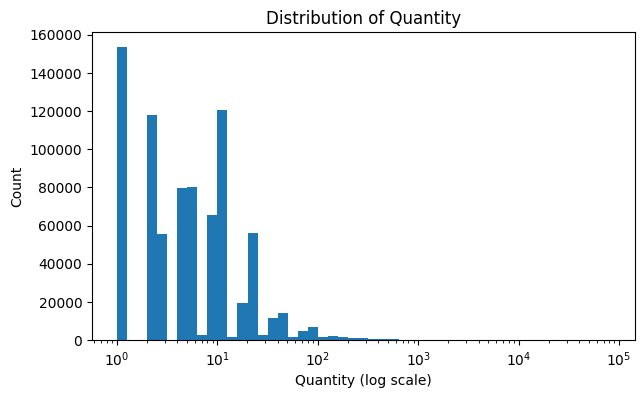

In [8]:
# =========================
# Brief exploratory analysis
# =========================

# 1. Quantity
print("Quantity")
display(clean_df["Quantity"].describe())

plt.figure(figsize=(7, 4))
plt.hist(clean_df["Quantity"], bins=np.logspace(
    np.log10(clean_df["Quantity"].min()),
    np.log10(clean_df["Quantity"].max()),
    50
))
plt.xscale("log")
plt.xlabel("Quantity (log scale)")
plt.ylabel("Count")
plt.title("Distribution of Quantity")
plt.show()

UnitPrice


count    805549.000000
mean          3.206561
std          29.199173
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: UnitPrice, dtype: float64

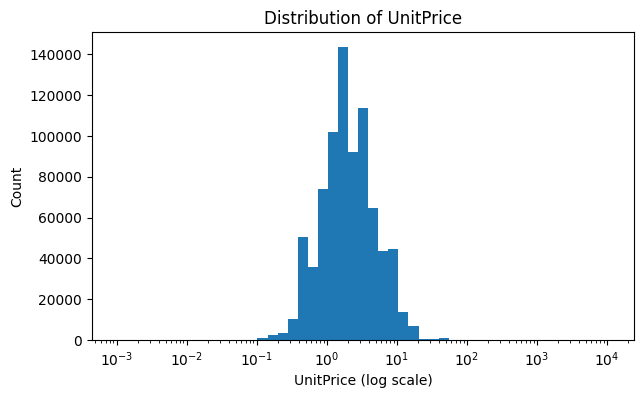

In [9]:
# 2. UnitPrice
print("UnitPrice")
display(clean_df["UnitPrice"].describe())

plt.figure(figsize=(7, 4))
plt.hist(clean_df["UnitPrice"], bins=np.logspace(
    np.log10(clean_df["UnitPrice"].min()),
    np.log10(clean_df["UnitPrice"].max()),
    50
))
plt.xscale("log")
plt.xlabel("UnitPrice (log scale)")
plt.ylabel("Count")
plt.title("Distribution of UnitPrice")
plt.show()

LineRevenue


count    805549.000000
mean         22.026505
std         224.041928
min           0.001000
25%           4.950000
50%          11.850000
75%          19.500000
max      168469.600000
Name: LineRevenue, dtype: float64

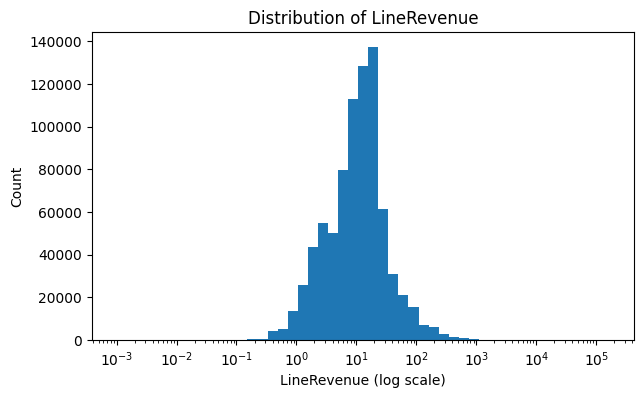

In [10]:
# 3. LineRevenue
print("LineRevenue")
display(clean_df["LineRevenue"].describe())

plt.figure(figsize=(7, 4))
plt.hist(clean_df["LineRevenue"], bins=np.logspace(
    np.log10(clean_df["LineRevenue"].min()),
    np.log10(clean_df["LineRevenue"].max()),
    50
))
plt.xscale("log")
plt.xlabel("LineRevenue (log scale)")
plt.ylabel("Count")
plt.title("Distribution of LineRevenue")
plt.show()

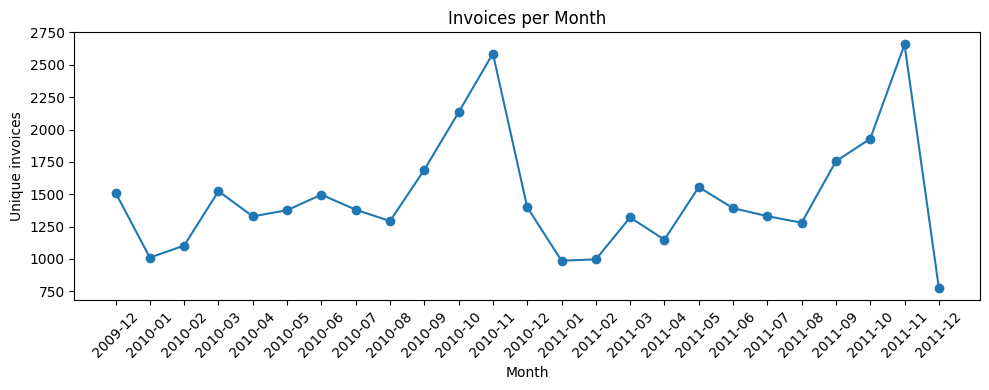

In [11]:
# 4. Unique invoices per month
invoices_per_month = (
    clean_df
    .assign(Month=clean_df["InvoiceDate"].dt.to_period("M"))
    .groupby("Month")["InvoiceNo"]
    .nunique()
)

plt.figure(figsize=(10, 4))
plt.plot(
    invoices_per_month.index.astype(str),
    invoices_per_month.values,
    marker="o"
)
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Unique invoices")
plt.title("Invoices per Month")
plt.tight_layout()
plt.show()

Number of countries: 41


Country
United Kingdom     725250
Germany             16694
EIRE                15743
France              13812
Netherlands          5088
Spain                3719
Belgium              3068
Switzerland          3011
Portugal             2446
Australia            1812
Channel Islands      1569
Italy                1468
Norway               1436
Sweden               1319
Cyprus               1155
Name: count, dtype: int64

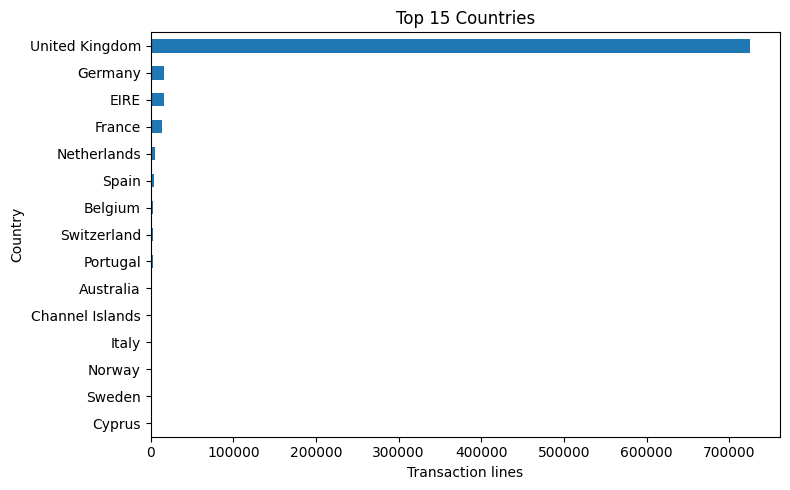

In [12]:
# 5. Country
country_counts = clean_df["Country"].value_counts()

print("Number of countries:", clean_df["Country"].nunique())
display(country_counts.head(15))

plt.figure(figsize=(8, 5))
country_counts.head(15).sort_values().plot(kind="barh")
plt.xlabel("Transaction lines")
plt.ylabel("Country")
plt.title("Top 15 Countries")
plt.tight_layout()
plt.show()

,StockCode,TransactionLines
0,85123A,5188
1,22423,3428
2,85099B,3360
3,84879,2777
4,20725,2678
5,21212,2654
6,21034,2141
7,47566,2121
8,20727,2117
9,22383,2100


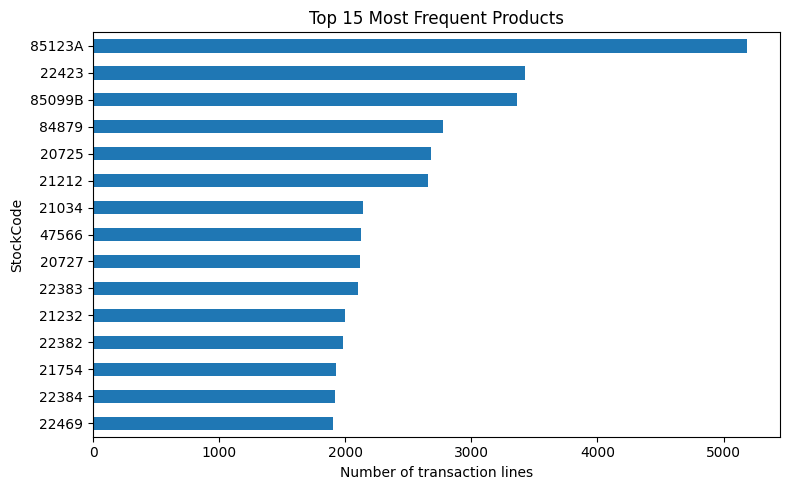

In [13]:
# 6. Most frequent products
product_counts = clean_df["StockCode"].value_counts().head(15)

display(
    pd.DataFrame({
        "StockCode": product_counts.index,
        "TransactionLines": product_counts.values
    })
)

plt.figure(figsize=(8, 5))
product_counts.sort_values().plot(kind="barh")
plt.xlabel("Number of transaction lines")
plt.ylabel("StockCode")
plt.title("Top 15 Most Frequent Products")
plt.tight_layout()
plt.show()

## 5. Customer-level feature engineering

The analytical grain is changed from invoice line to customer.

The core representation uses RFM-style behavior plus selected purchasing characteristics:

- **Recency** — days since the customer's most recent purchase;
- **Frequency** — number of distinct purchase invoices;
- **MonetaryValue** — total positive purchase value;
- **AverageOrderValue** — average purchase value per invoice;
- **UniqueProducts** — number of distinct purchased products;
- **CustomerTenureDays** — observed time from first purchase to the reference date.

Additional variables are calculated for exploratory auditing but are not all used for clustering, avoiding unnecessary redundancy.

In [14]:
# Reference date: one day after the last transaction
reference_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create date-only variable for ActiveDays
customer_data = clean_df.copy()
customer_data["PurchaseDate"] = customer_data["InvoiceDate"].dt.normalize()

# -------------------------
# Main customer aggregation
# -------------------------

customer_features = (
    customer_data
    .groupby("CustomerID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        FirstPurchase=("InvoiceDate", "min"),
        Frequency=("InvoiceNo", "nunique"),
        MonetaryValue=("LineRevenue", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        TotalItems=("Quantity", "sum"),
        ActiveDays=("PurchaseDate", "nunique")
    )
)

# -------------------------
# RFM: Recency
# -------------------------

customer_features["Recency"] = (
    reference_date - customer_features["LastPurchase"]
).dt.days

# -------------------------
# Additional features
# -------------------------

customer_features["AverageOrderValue"] = (
    customer_features["MonetaryValue"]
    / customer_features["Frequency"]
)

customer_features["AverageItemsPerInvoice"] = (
    customer_features["TotalItems"]
    / customer_features["Frequency"]
)

customer_features["CustomerTenureDays"] = (
    reference_date - customer_features["FirstPurchase"]
).dt.days

# Remove intermediate date columns
customer_features = customer_features.drop(
    columns=["LastPurchase", "FirstPurchase"]
)

# Put RFM first
customer_features = customer_features[
    [
        "Recency",
        "Frequency",
        "MonetaryValue",
        "AverageOrderValue",
        "UniqueProducts",
        "TotalItems",
        "AverageItemsPerInvoice",
        "ActiveDays",
        "CustomerTenureDays"
    ]
]

display(customer_features.head())

print("Shape:", customer_features.shape)
print("\nMissing values:")
print(customer_features.isna().sum())

display(customer_features.describe().T)

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueProducts,TotalItems,AverageItemsPerInvoice,ActiveDays,CustomerTenureDays
CustomerID,,,,,,,,,
12346,326,12,77556.46,6463.038333,27,74285,6190.416667,8,726
12347,2,8,5633.32,704.165000,126,3286,410.750000,8,404
12348,75,5,2019.40,403.880000,25,2714,542.800000,5,438
12349,19,4,4428.69,1107.172500,138,1624,406.000000,4,589
12350,310,1,334.40,334.400000,17,197,197.000000,1,310


Shape: (5878, 9)

Missing values:
Recency                   0
Frequency                 0
MonetaryValue             0
AverageOrderValue         0
UniqueProducts            0
TotalItems                0
AverageItemsPerInvoice    0
ActiveDays                0
CustomerTenureDays        0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Recency,5878.0,201.331916,209.338707,1.00,26.0000,96.000000,380.00,739.00
Frequency,5878.0,6.289384,13.009406,1.00,1.0000,3.000000,7.00,398.00
MonetaryValue,5878.0,3018.616737,14737.731040,2.95,348.7625,898.915000,2307.09,608821.65
AverageOrderValue,5878.0,391.726538,1215.071054,2.95,181.6525,285.070500,420.57,84236.25
UniqueProducts,5878.0,81.989112,116.484552,1.00,19.0000,45.000000,103.00,2550.00
TotalItems,5878.0,1821.396223,8963.011855,1.00,190.0000,491.500000,1376.00,367193.00
AverageItemsPerInvoice,5878.0,251.125203,1424.751476,1.00,93.5000,157.708333,262.00,87167.00
ActiveDays,5878.0,5.632358,9.999783,1.00,1.0000,3.000000,6.00,255.00
CustomerTenureDays,5878.0,474.711637,223.098342,1.00,313.0000,530.000000,668.00,739.00


### External customer metadata

Country and cancellation behavior are retained as external metadata. They are not used to form the primary clusters, which allows them to be used later for post-hoc interpretation rather than imposing geography or return behavior on the segmentation.

In [15]:
# Transactions with known customer
metadata_df = df.loc[df["CustomerID"].notna()].copy()

metadata_df["CustomerID"] = (
    metadata_df["CustomerID"]
    .astype("int64")
    .astype("string")
)

metadata_df["IsCancellation"] = (
    metadata_df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

# One row per invoice
invoice_metadata = (
    metadata_df[
        ["CustomerID", "InvoiceNo", "Country", "IsCancellation"]
    ]
    .drop_duplicates()
)


# --------------------------------
# Primary country
# --------------------------------

primary_country = (
    invoice_metadata
    .loc[~invoice_metadata["IsCancellation"]]
    .groupby(["CustomerID", "Country"])
    .size()
    .rename("InvoiceCount")
    .reset_index()
    .sort_values(
        ["CustomerID", "InvoiceCount"],
        ascending=[True, False]
    )
    .drop_duplicates("CustomerID")
    .set_index("CustomerID")["Country"]
    .rename("PrimaryCountry")
)


# --------------------------------
# Number of countries
# --------------------------------

number_countries = (
    invoice_metadata
    .loc[~invoice_metadata["IsCancellation"]]
    .groupby("CustomerID")["Country"]
    .nunique()
    .rename("NumberCountries")
)


# --------------------------------
# Cancellation metrics
# --------------------------------

cancellation_stats = (
    invoice_metadata
    .groupby("CustomerID")
    .agg(
        TotalInvoices=("InvoiceNo", "nunique"),
        CancellationCount=("IsCancellation", "sum")
    )
)

cancellation_stats["CancellationRate"] = (
    cancellation_stats["CancellationCount"]
    / cancellation_stats["TotalInvoices"]
)


# --------------------------------
# Final metadata table
# --------------------------------

customer_metadata = (
    primary_country
    .to_frame()
    .join(number_countries)
    .join(cancellation_stats)
)

# Keep only customers present in customer_features
customer_metadata = customer_metadata.reindex(
    customer_features.index
)

display(customer_metadata.head())
print(customer_metadata.shape)

,PrimaryCountry,NumberCountries,TotalInvoices,CancellationCount,CancellationRate
CustomerID,,,,,
12346,United Kingdom,1,17,5,0.294118
12347,Iceland,1,8,0,0.000000
12348,Finland,1,5,0,0.000000
12349,Italy,1,5,1,0.200000
12350,Norway,1,1,0,0.000000


(5878, 5)


## 6. Customer feature-space audit

,count,mean,std,min,25%,50%,75%,max
Recency,5878.0,201.331916,209.338707,1.00,26.0000,96.000000,380.00,739.00
Frequency,5878.0,6.289384,13.009406,1.00,1.0000,3.000000,7.00,398.00
MonetaryValue,5878.0,3018.616737,14737.731040,2.95,348.7625,898.915000,2307.09,608821.65
AverageOrderValue,5878.0,391.726538,1215.071054,2.95,181.6525,285.070500,420.57,84236.25
UniqueProducts,5878.0,81.989112,116.484552,1.00,19.0000,45.000000,103.00,2550.00
TotalItems,5878.0,1821.396223,8963.011855,1.00,190.0000,491.500000,1376.00,367193.00
AverageItemsPerInvoice,5878.0,251.125203,1424.751476,1.00,93.5000,157.708333,262.00,87167.00
ActiveDays,5878.0,5.632358,9.999783,1.00,1.0000,3.000000,6.00,255.00
CustomerTenureDays,5878.0,474.711637,223.098342,1.00,313.0000,530.000000,668.00,739.00


,Skewness
AverageOrderValue,57.008610
AverageItemsPerInvoice,47.873021
MonetaryValue,25.314235
TotalItems,21.564661
Frequency,12.639951
ActiveDays,9.998913
UniqueProducts,6.224360
Recency,0.887198
CustomerTenureDays,-0.621348


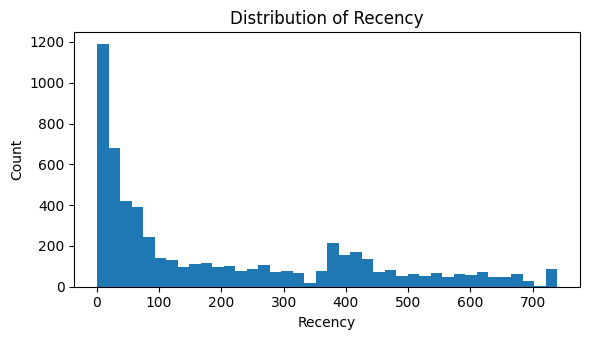

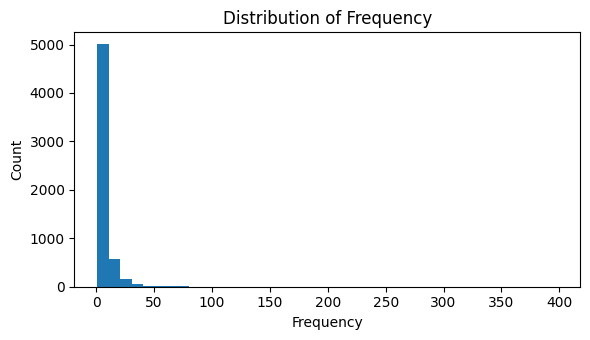

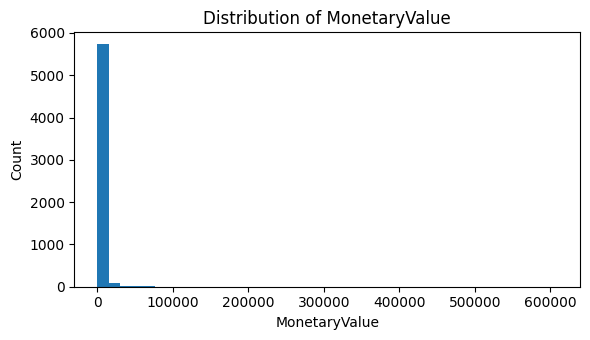

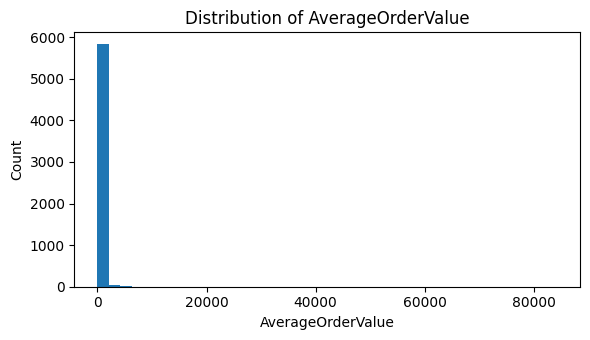

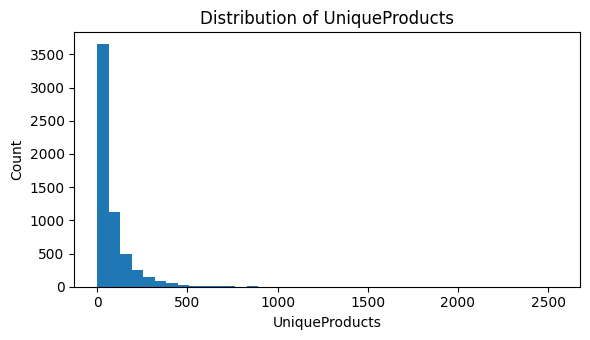

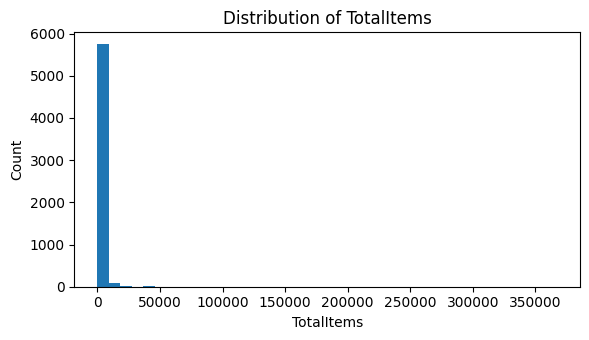

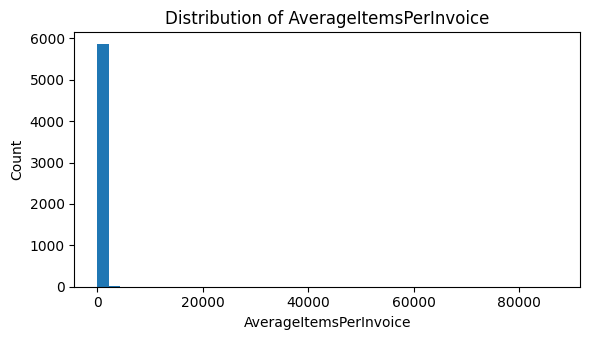

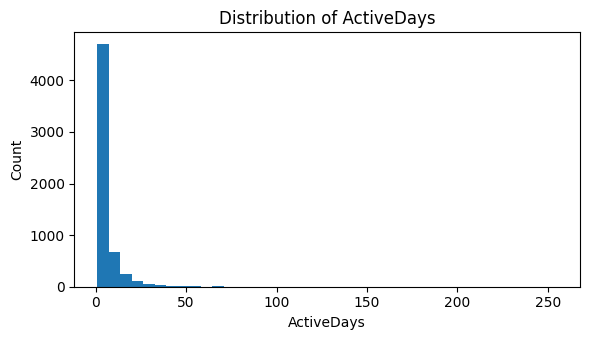

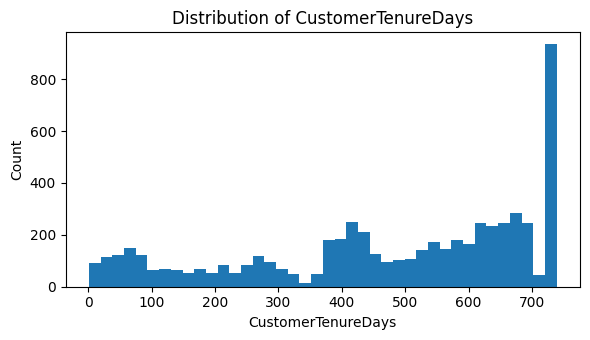

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueProducts,TotalItems,AverageItemsPerInvoice,ActiveDays,CustomerTenureDays
Recency,1.000000,-0.257013,-0.125080,-0.027813,-0.325477,-0.111201,0.002884,-0.295471,0.284100
Frequency,-0.257013,1.000000,0.629570,0.035110,0.693113,0.577018,0.013057,0.968489,0.271755
MonetaryValue,-0.125080,0.629570,1.000000,0.267103,0.407043,0.873558,0.131582,0.554207,0.130258
AverageOrderValue,-0.027813,0.035110,0.267103,1.000000,0.051937,0.257786,0.529356,0.028383,-0.006822
UniqueProducts,-0.325477,0.693113,0.407043,0.051937,1.000000,0.391361,0.023620,0.706344,0.273905
TotalItems,-0.111201,0.577018,0.873558,0.257786,0.391361,1.000000,0.355897,0.514568,0.131570
AverageItemsPerInvoice,0.002884,0.013057,0.131582,0.529356,0.023620,0.355897,1.000000,0.009992,0.002296
ActiveDays,-0.295471,0.968489,0.554207,0.028383,0.706344,0.514568,0.009992,1.000000,0.300411
CustomerTenureDays,0.284100,0.271755,0.130258,-0.006822,0.273905,0.131570,0.002296,0.300411,1.000000


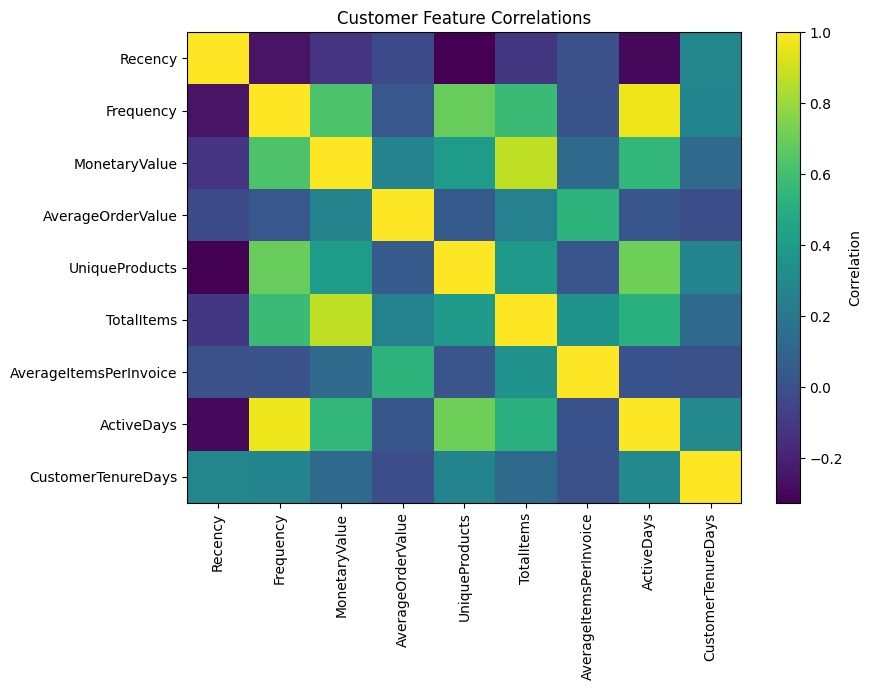

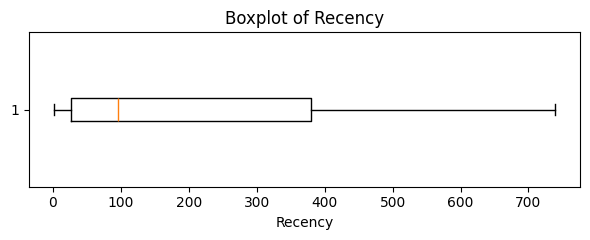

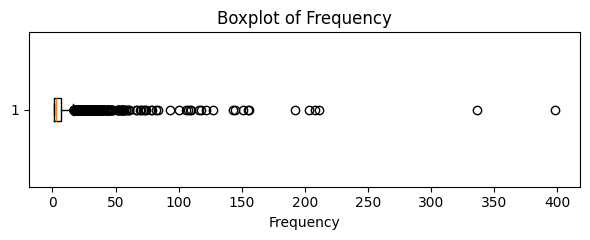

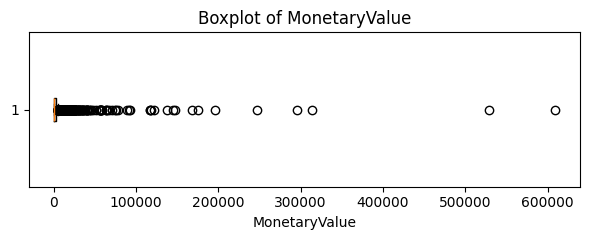

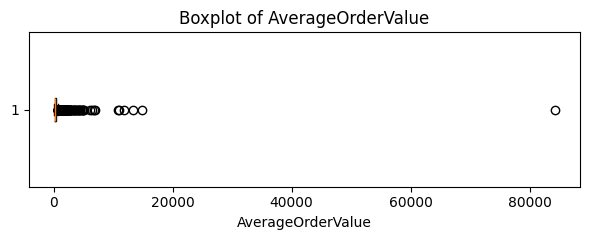

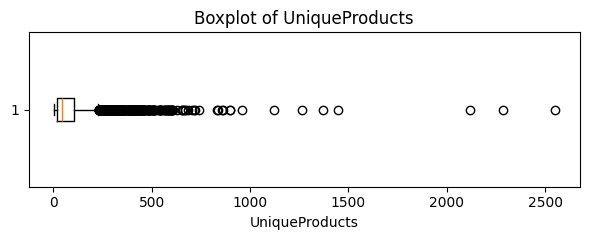

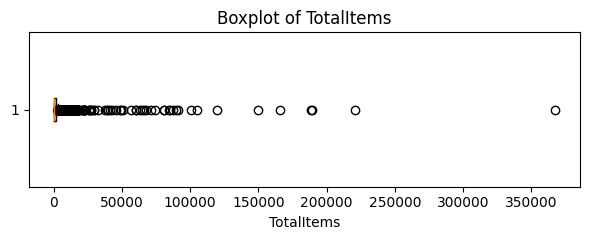

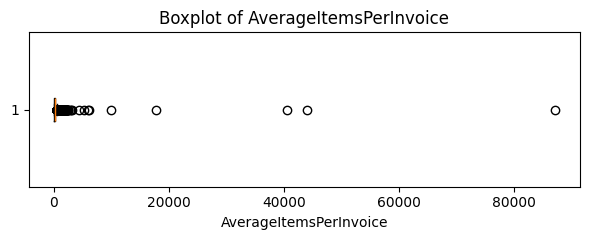

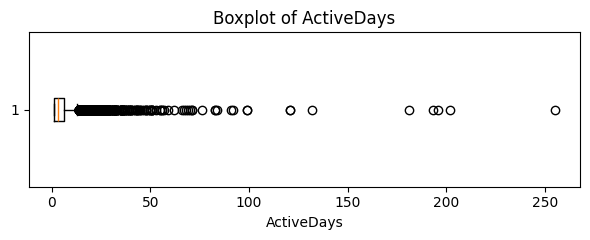

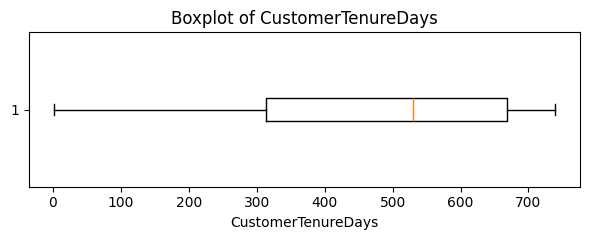


Top customers by Recency:


,Recency
CustomerID,
17592,739
12636,739
13526,738
17087,738
17056,738
14654,738
15833,738
17818,738
17606,737



Top customers by Frequency:


,Frequency
CustomerID,
14911,398
12748,336
17841,211
15311,208
13089,203
14606,192
14156,156
17850,155
14646,151



Top customers by MonetaryValue:


...


Top customers by ActiveDays:


,ActiveDays
CustomerID,
14911,255
12748,202
15311,196
17841,193
14606,181
13089,132
14156,121
14527,121
12971,99



Top customers by CustomerTenureDays:


,CustomerTenureDays
CustomerID,
12362,739
14040,739
18087,739
13767,739
13758,739
18102,739
16167,739
12913,739
14156,739


,min,median,mean,std,max,skewness
Recency,1.00,96.000000,201.331916,209.338707,739.00,0.887198
Frequency,1.00,3.000000,6.289384,13.009406,398.00,12.639951
MonetaryValue,2.95,898.915000,3018.616737,14737.731040,608821.65,25.314235
AverageOrderValue,2.95,285.070500,391.726538,1215.071054,84236.25,57.008610
UniqueProducts,1.00,45.000000,81.989112,116.484552,2550.00,6.224360
TotalItems,1.00,491.500000,1821.396223,8963.011855,367193.00,21.564661
AverageItemsPerInvoice,1.00,157.708333,251.125203,1424.751476,87167.00,47.873021
ActiveDays,1.00,3.000000,5.632358,9.999783,255.00,9.998913
CustomerTenureDays,1.00,530.000000,474.711637,223.098342,739.00,-0.621348


In [16]:
# =========================
# Feature-space audit
# =========================

# 1. Descriptive statistics
display(customer_features.describe().T)


# 2. Skewness
skewness = (
    customer_features
    .skew()
    .sort_values(ascending=False)
    .rename("Skewness")
)

display(skewness.to_frame())


# 3. Histograms
for col in customer_features.columns:
    plt.figure(figsize=(6, 3.5))
    plt.hist(customer_features[col], bins=40)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


# 4. Correlations
correlation_matrix = customer_features.corr()

display(correlation_matrix)

plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix, aspect="auto")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)
plt.colorbar(label="Correlation")
plt.title("Customer Feature Correlations")
plt.tight_layout()
plt.show()


# 5. Boxplots
for col in customer_features.columns:
    plt.figure(figsize=(6, 2.5))
    plt.boxplot(customer_features[col], vert=False)
    plt.xlabel(col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()


# 6. Extreme customers
# Show the largest observations for each feature
for col in customer_features.columns:
    print(f"\nTop customers by {col}:")
    display(
        customer_features[[col]]
        .sort_values(col, ascending=False)
        .head(10)
    )


# 7. Scale comparison
scale_summary = pd.DataFrame({
    "min": customer_features.min(),
    "median": customer_features.median(),
    "mean": customer_features.mean(),
    "std": customer_features.std(),
    "max": customer_features.max(),
    "skewness": customer_features.skew()
})

display(scale_summary)

The customer feature space contains substantial scale differences, long right tails, and partially redundant variables. In particular, purchase frequency and active days are closely related, while total spend and total items also overlap strongly.

The clustering representation is therefore kept deliberately compact and transformed before distance-based modeling.

In [17]:
clustering_features = [
    "Recency",
    "Frequency",
    "MonetaryValue",
    "AverageOrderValue",
    "UniqueProducts",
    "CustomerTenureDays",
]

## 7. Feature transformation

For non-negative, strongly skewed behavioral variables, `log1p` compresses long tails before standardization:

\begin{equation}
x' = \log(1+x)
\end{equation}

`StandardScaler` is then applied so that no feature dominates Euclidean distance solely because of its numerical scale.

In [18]:
X_customer = customer_features[clustering_features].copy()

# Verify that log1p is valid
print("Minimum values:")
display(X_customer.min())

assert (X_customer >= 0).all().all(), \
    "log1p requires values greater than or equal to 0."


# Transformation pipeline
preprocessor = Pipeline([
    (
        "log1p",
        FunctionTransformer(
            np.log1p,
            feature_names_out="one-to-one"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])


# Fit and transform
X_transformed_array = preprocessor.fit_transform(X_customer)

# Convert back to DataFrame for easier inspection
X_transformed = pd.DataFrame(
    X_transformed_array,
    index=X_customer.index,
    columns=clustering_features
)

display(X_transformed.head())

print("\nMeans after transformation:")
display(X_transformed.mean())

print("\nStandard deviations after transformation:")
display(X_transformed.std())

Minimum values:


Recency               1.00
Frequency             1.00
MonetaryValue         2.95
AverageOrderValue     2.95
UniqueProducts        1.00
CustomerTenureDays    1.00
dtype: float64

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueProducts,CustomerTenureDays
CustomerID,,,,,,
12346,0.856701,1.254496,3.186625,4.264242,-0.350753,0.747205
12347,-2.151979,0.800166,1.297127,1.253001,0.889667,0.085547
12348,-0.079138,0.299207,0.558100,0.498904,-0.411550,0.176717
12349,-0.935308,0.073946,1.123790,1.867373,0.963738,0.511056
12350,0.824527,-1.058146,-0.735888,0.243026,-0.713229,-0.213134



Means after transformation:


Recency              -5.052856e-16
Frequency             2.381370e-16
MonetaryValue        -4.351742e-16
AverageOrderValue     5.705617e-16
UniqueProducts       -3.550900e-16
CustomerTenureDays    1.241455e-15
dtype: float64


Standard deviations after transformation:


Recency               1.000085
Frequency             1.000085
MonetaryValue         1.000085
AverageOrderValue     1.000085
UniqueProducts        1.000085
CustomerTenureDays    1.000085
dtype: float64

## 8. PCA visualization

PCA is used only as a visualization tool. The clustering algorithms are fitted in the full transformed feature space rather than on the two-dimensional projection.

Explained variance ratio:
PC1: 0.5445533239459549
PC2: 0.21086397508383667
Total explained variance: 0.7554172990297916


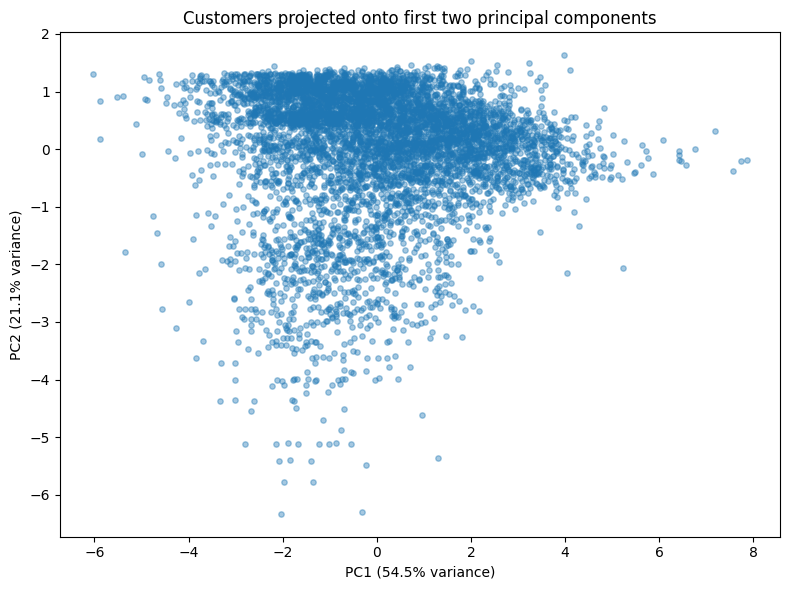

In [19]:
# =========================
# PCA for visualization
# =========================

pca = PCA(n_components=2)

X_pca_array = pca.fit_transform(X_transformed)

X_pca = pd.DataFrame(
    X_pca_array,
    index=X_transformed.index,
    columns=["PC1", "PC2"]
)

explained_variance_ratio = pca.explained_variance_ratio_

print("Explained variance ratio:")
print("PC1:", explained_variance_ratio[0])
print("PC2:", explained_variance_ratio[1])
print(
    "Total explained variance:",
    explained_variance_ratio.sum()
)

# Plot customers without cluster labels
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    alpha=0.4,
    s=15
)

plt.xlabel(
    f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)"
)
plt.title("Customers projected onto first two principal components")
plt.tight_layout()
plt.show()

## 9. K-Means model selection

Candidate values of \(k\) are compared using inertia, silhouette score, Davies-Bouldin index, and Calinski-Harabasz score.

Multiple K-Means initializations are used consistently so that model-selection metrics are not driven by an unlucky centroid initialization.

In [20]:
k_values = range(2, 15)

results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = kmeans.fit_predict(X_transformed)

    results.append({
        "k": k,
        "Inertia": kmeans.inertia_,
        "Silhouette": silhouette_score(
            X_transformed,
            labels
        ),
        "DaviesBouldin": davies_bouldin_score(
            X_transformed,
            labels
        ),
        "CalinskiHarabasz": calinski_harabasz_score(
            X_transformed,
            labels
        )
    })

kmeans_results = pd.DataFrame(results)

display(kmeans_results)

,k,Inertia,Silhouette,DaviesBouldin,CalinskiHarabasz
0,2,22634.899729,0.317147,1.197638,3279.541685
1,3,17918.903119,0.330317,1.107062,2844.089940
2,4,14783.022556,0.267518,1.175379,2713.244942
3,5,13152.317102,0.234400,1.238029,2468.880451
4,6,12027.289269,0.233968,1.257110,2269.337867
5,7,11243.467834,0.226764,1.284945,2090.822455
6,8,10541.372259,0.209803,1.292020,1967.018841
7,9,9915.928648,0.207815,1.325993,1875.680183
8,10,9395.354850,0.210463,1.327381,1795.467574
9,11,8980.605473,0.200031,1.358562,1717.354288


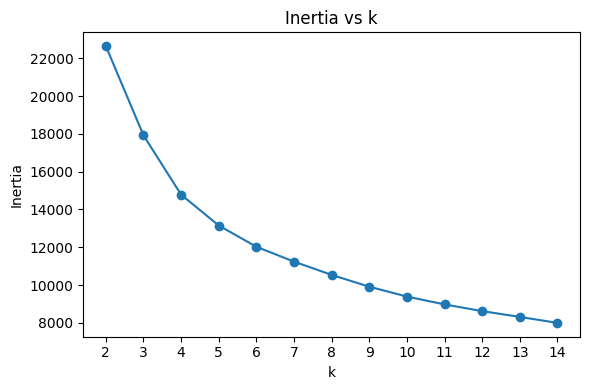

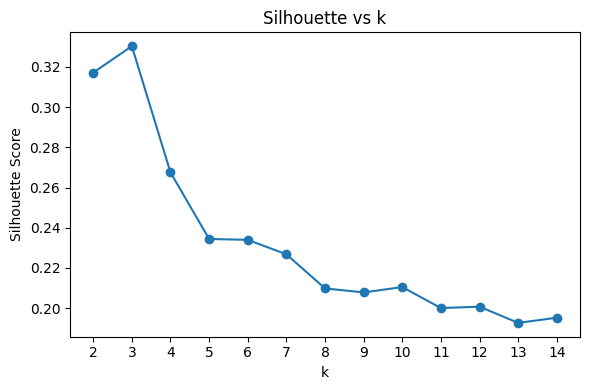

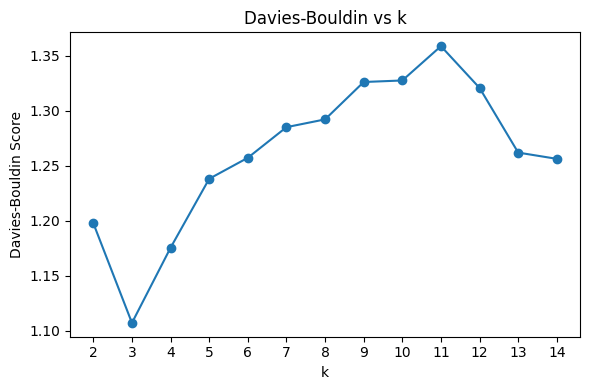

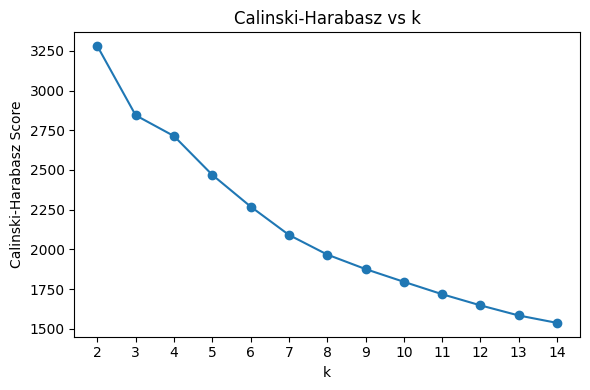

In [21]:
# Inertia vs k
plt.figure(figsize=(6, 4))
plt.plot(
    kmeans_results["k"],
    kmeans_results["Inertia"],
    marker="o"
)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Inertia vs k")
plt.xticks(kmeans_results["k"])
plt.tight_layout()
plt.show()


# Silhouette vs k
plt.figure(figsize=(6, 4))
plt.plot(
    kmeans_results["k"],
    kmeans_results["Silhouette"],
    marker="o"
)
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette vs k")
plt.xticks(kmeans_results["k"])
plt.tight_layout()
plt.show()


# Davies-Bouldin vs k
plt.figure(figsize=(6, 4))
plt.plot(
    kmeans_results["k"],
    kmeans_results["DaviesBouldin"],
    marker="o"
)
plt.xlabel("k")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin vs k")
plt.xticks(kmeans_results["k"])
plt.tight_layout()
plt.show()


# Calinski-Harabasz vs k
plt.figure(figsize=(6, 4))
plt.plot(
    kmeans_results["k"],
    kmeans_results["CalinskiHarabasz"],
    marker="o"
)
plt.xlabel("k")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz vs k")
plt.xticks(kmeans_results["k"])
plt.tight_layout()
plt.show()

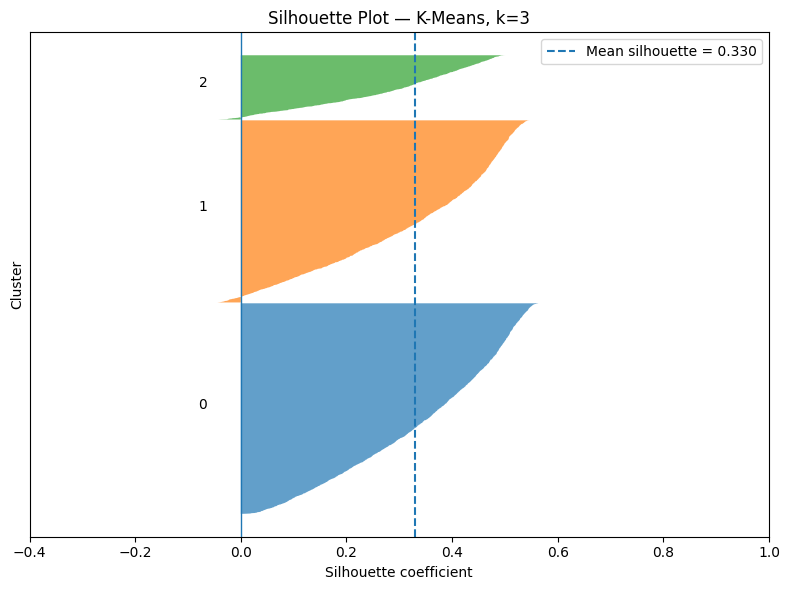

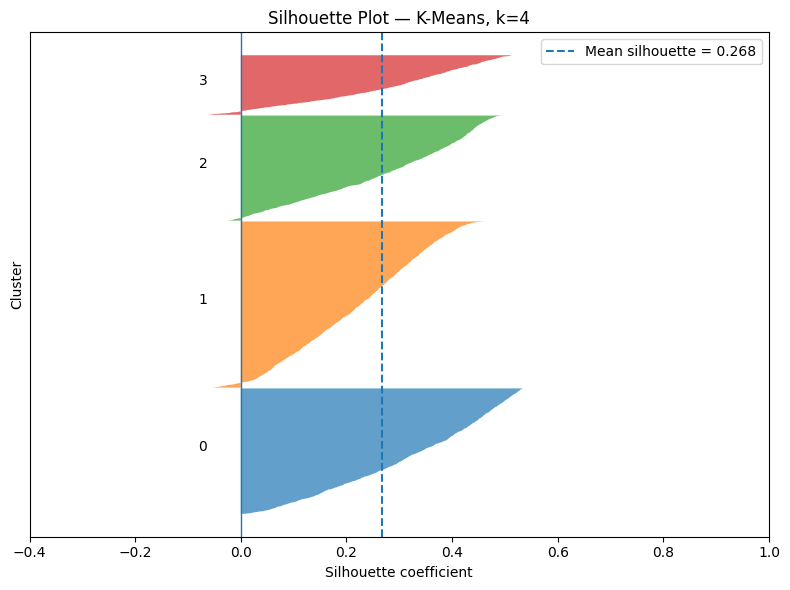

In [22]:
for k in [3, 4]:

    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = kmeans.fit_predict(X_transformed)

    silhouette_values = silhouette_samples(
        X_transformed,
        labels
    )

    silhouette_avg = silhouette_score(
        X_transformed,
        labels
    )

    plt.figure(figsize=(8, 6))

    y_lower = 10

    for cluster in range(k):

        cluster_values = silhouette_values[
            labels == cluster
        ]

        cluster_values.sort()

        cluster_size = cluster_values.shape[0]
        y_upper = y_lower + cluster_size

        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_values,
            alpha=0.7
        )

        plt.text(
            -0.08,
            y_lower + cluster_size / 2,
            str(cluster)
        )

        y_lower = y_upper + 10

    # Average silhouette
    plt.axvline(
        silhouette_avg,
        linestyle="--",
        label=f"Mean silhouette = {silhouette_avg:.3f}"
    )

    # Reference at zero
    plt.axvline(
        0,
        linewidth=1
    )

    plt.xlabel("Silhouette coefficient")
    plt.ylabel("Cluster")
    plt.title(f"Silhouette Plot — K-Means, k={k}")
    plt.xlim(-0.4, 1)
    plt.yticks([])
    plt.legend()
    plt.tight_layout()
    plt.show()

The internal metrics support a compact solution, and the three-cluster representation offers the strongest balance between separation and interpretability among the candidate solutions examined.

## 10. Three-cluster customer segmentation

In [23]:
k_selected = 3

main_k_means = KMeans(
    n_clusters=k_selected,
    random_state=RANDOM_STATE,
    n_init=20,
)

k_mean_labels = main_k_means.fit_predict(X_transformed)

In [24]:
X_customer_labeled = X_customer.copy().assign(
    labels = k_mean_labels
)
X_customer_labeled

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueProducts,CustomerTenureDays,labels
CustomerID,,,,,,,
12346,326,12,77556.46,6463.038333,27,726,1
12347,2,8,5633.32,704.165000,126,404,1
12348,75,5,2019.40,403.880000,25,438,1
12349,19,4,4428.69,1107.172500,138,589,1
12350,310,1,334.40,334.400000,17,310,0
...,...,...,...,...,...,...,...
18283,4,22,2736.65,124.393182,352,658,1
18284,432,1,461.68,461.680000,28,432,0
18285,661,1,427.00,427.000000,12,661,0


In [25]:
def cluster_summary(X_customer_labeled):

    clustered_summary = (X_customer_labeled.
    groupby(by = "labels", as_index=False).
    agg(["mean", "median"]))

    clustered_summary.insert(
        0,
        ("cluster_size", "count"),
        X_customer_labeled.groupby("labels").size()
    )   

    return clustered_summary

cluster_summary(X_customer_labeled)

cluster_size labels     Recency         Frequency        MonetaryValue  \
         count               mean median       mean median          mean   
0         2708      0  360.411374  381.0   2.187223    2.0    553.975891   
1         2343      1   74.180111   31.0  12.568075    8.0   6705.059455   
2          827      2   40.666264   30.0   1.933495    1.0    644.870811   

            AverageOrderValue             UniqueProducts         \
     median              mean      median           mean median   
0   414.165        279.635136  218.184167      29.685377   23.0   
1  2927.380        535.207492  358.942000     158.454972  120.0   
2   430.150        352.267818  265.140000      36.619105   26.0   

  CustomerTenureDays         
                mean median  
0         501.159897  514.5  
1         584.351686  642.0  
2          77.482467   65.0

The selected solution produces three behaviorally distinct customer profiles:

- a large group of established customers with low recent activity and relatively low historical purchasing intensity;
- a frequent, high-value group with recent activity, greater spend, and broad product diversity;
- a recent, limited-history group whose low purchase frequency is accompanied by short observed tenure.

The segment names are descriptive rather than causal: clustering describes observed behavior but does not explain why customers behave that way.

In [26]:
def labels_over_pc2_plot(X_pca_labeled, title="Customers projected onto PCA"):
    labels = np.sort(X_pca_labeled["labels"].unique())
    cmap = plt.get_cmap("tab10")

    plt.figure(figsize=(8, 6))

    for i, label in enumerate(labels):
        group_df = X_pca_labeled.loc[
            X_pca_labeled["labels"] == label
        ]

        plt.scatter(
            group_df["PC1"],
            group_df["PC2"],
            alpha=0.4,
            s=15,
            color=cmap(i % 10),
            label=f"Cluster {label}",
        )

    plt.xlabel(
        f"PC1 ({explained_variance_ratio[0] * 100:.1f}% variance)"
    )
    plt.ylabel(
        f"PC2 ({explained_variance_ratio[1] * 100:.1f}% variance)"
    )
    plt.legend()
    plt.title(title)
    plt.tight_layout()
    plt.show()

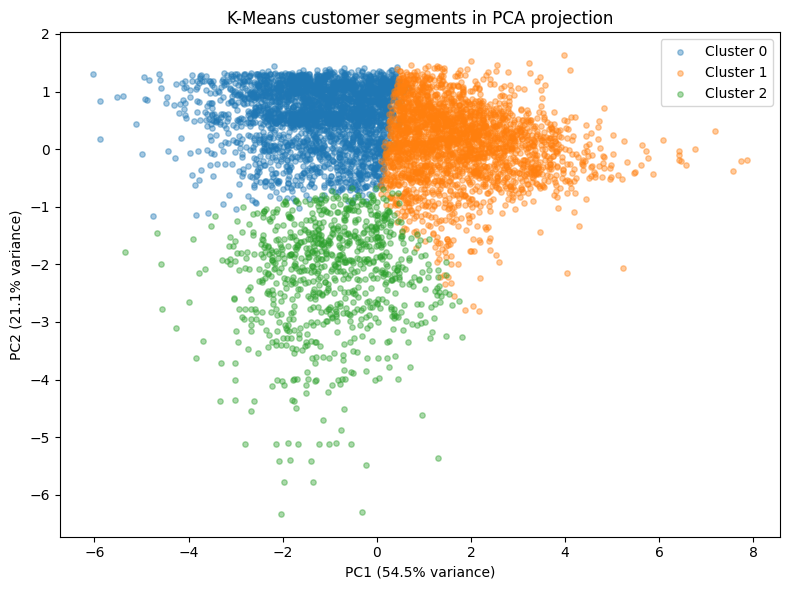

In [27]:
X_pca_labeled = X_pca.copy().assign(labels=k_mean_labels)
labels_over_pc2_plot(
    X_pca_labeled,
    title="K-Means customer segments in PCA projection",
)

## 11. K-Means stability

A single K-Means initialization can converge to noticeably different local solutions. The stability check therefore compares several random seeds while using 20 initializations per fit.

Adjusted Rand Index (ARI) compares partitions without assuming that numeric cluster labels have the same meaning across runs.

In [28]:
seeds = [0, 1, 2, 3, 4, 42, 100]
stability_results = []

for seed in seeds:
    model = KMeans(
        n_clusters=k_selected,
        random_state=seed,
        n_init=20,
    )

    labels = model.fit_predict(X_transformed)

    stability_results.append({
        "seed": seed,
        "ARI": adjusted_rand_score(
            k_mean_labels,
            labels,
        ),
        "Inertia": model.inertia_,
    })

stability_results = pd.DataFrame(stability_results)
display(stability_results)

,seed,ARI,Inertia
0,0,0.997055,17918.875835
1,1,1.000000,17918.925300
2,2,0.998712,17918.876112
3,3,1.000000,17918.905422
4,4,1.000000,17918.912310
5,42,1.000000,17918.903119
6,100,1.000000,17918.953534


The multiple-initialization fits converge to nearly identical low-inertia solutions, showing that the selected K-Means segmentation is substantially more stable than a single-initialization fit.

## 12. DBSCAN

DBSCAN is used as a density-based alternative. Unlike K-Means, it can label low-density customers as noise and does not require specifying the number of clusters in advance.

In [29]:
eps_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3]
min_samples_values = [5, 10, 20, 30]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_transformed)

        # Noise = label -1
        noise_mask = labels == -1
        non_noise_mask = ~noise_mask

        n_noise = noise_mask.sum()
        noise_pct = 100 * n_noise / len(labels)

        # Number of actual clusters, excluding noise
        cluster_labels = set(labels)
        cluster_labels.discard(-1)
        n_clusters = len(cluster_labels)

        # Silhouette only on non-noise observations
        silhouette = np.nan

        non_noise_labels = labels[non_noise_mask]

        # Need at least 2 clusters and enough observations
        if (
            len(np.unique(non_noise_labels)) >= 2
            and len(non_noise_labels) > len(np.unique(non_noise_labels))
        ):
            silhouette = silhouette_score(
                X_transformed.loc[non_noise_mask],
                non_noise_labels
            )

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
            "noise_pct": noise_pct,
            "silhouette": silhouette
        })

dbscan_results = pd.DataFrame(dbscan_results)

display(
    dbscan_results.sort_values(
        ["silhouette", "noise_pct"],
        ascending=[False, True]
    )
)

,eps,min_samples,n_clusters,n_noise,noise_pct,silhouette
20,1.3,5,2,44,0.748554,0.536837
7,0.5,30,3,3579,60.888057,0.326698
6,0.5,20,3,2924,49.744811,0.316595
12,0.9,5,3,154,2.619939,0.252113
5,0.5,10,4,1867,31.762504,0.120897
2,0.3,20,2,5295,90.081660,0.069679
1,0.3,10,14,4677,79.567880,-0.020298
8,0.7,5,5,374,6.362708,-0.052331
4,0.5,5,10,1183,20.125893,-0.075463
3,0.3,30,3,5465,92.973801,-0.077928


In [30]:
dbscan_candidates = [
    {"eps": 0.9, "min_samples": 5},  # 3 clusters, low noise
    {"eps": 1.3, "min_samples": 5},  # 2 clusters, highest silhouette
]

In [31]:
dbscan_09_5 = DBSCAN(**dbscan_candidates[0])
dbscan_13_5 = DBSCAN(**dbscan_candidates[1])

In [32]:
labels_09_5 = dbscan_09_5.fit_predict(X_transformed)
labels_13_5 = dbscan_13_5.fit_predict(X_transformed)

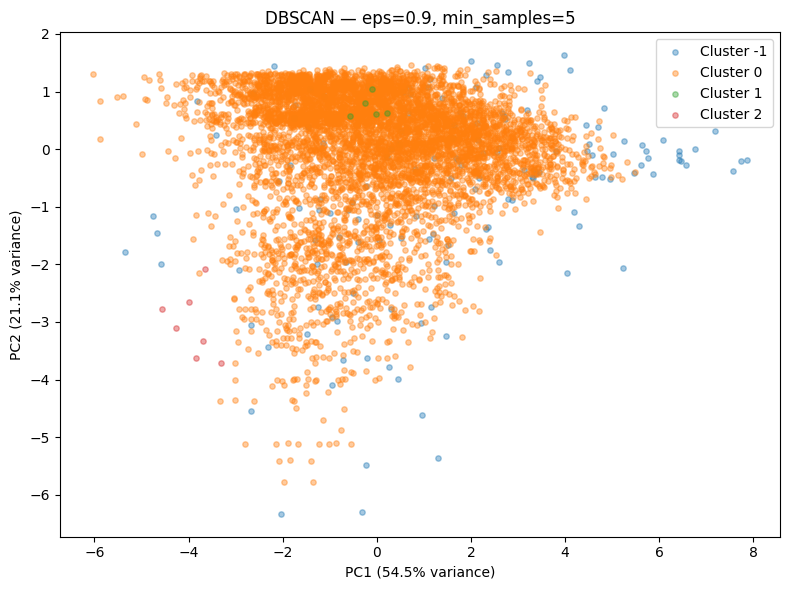

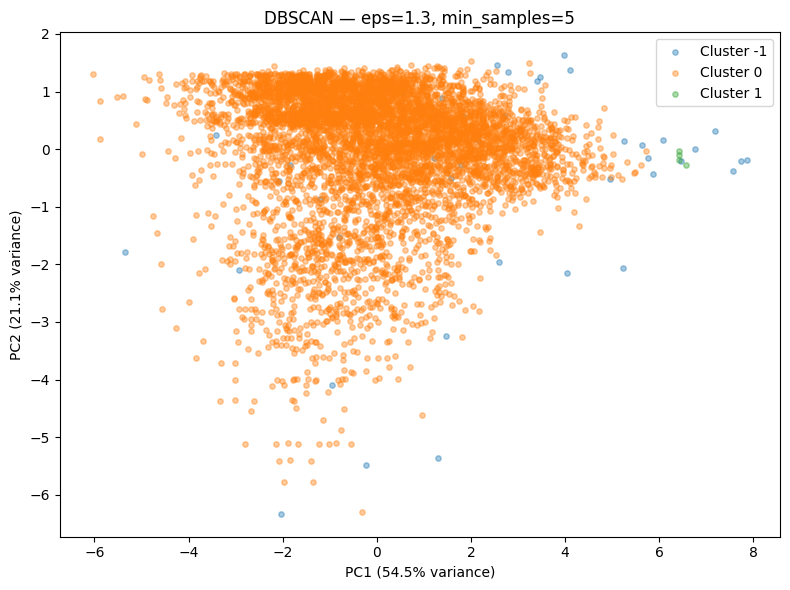

In [33]:
X_pca_labeled_09_5 = X_pca.copy().assign(labels=labels_09_5)
X_pca_labeled_13_5 = X_pca.copy().assign(labels=labels_13_5)

labels_over_pc2_plot(
    X_pca_labeled_09_5,
    title="DBSCAN — eps=0.9, min_samples=5",
)
labels_over_pc2_plot(
    X_pca_labeled_13_5,
    title="DBSCAN — eps=1.3, min_samples=5",
)

In [34]:
print("eps=0.9, min_samples=5")
display(
    pd.Series(labels_09_5)
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

print("eps=1.3, min_samples=5")
display(
    pd.Series(labels_13_5)
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

eps=0.9, min_samples=5


,count
-1,154
0,5712
1,5
2,7


eps=1.3, min_samples=5


,count
-1,44
0,5830
1,4


DBSCAN does not provide a balanced general-purpose segmentation for this customer population. The most practical parameter settings produce one dominant cluster plus a handful of micro-clusters and noise points.

This makes DBSCAN useful for understanding density and isolated customers, but less suitable than K-Means for the primary business segmentation in this case.

## 13. Gaussian Mixture Models

Gaussian Mixture Models provide a probabilistic alternative to hard clustering. AIC and BIC are used to compare component counts, while multiple initializations reduce sensitivity to local optima.

In [35]:
gmm_results_10_init = []

for n_components in range(1, 11):

    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=10
    )

    gmm.fit(X_transformed)

    gmm_results_10_init.append({
        "n_components": n_components,
        "AIC": gmm.aic(X_transformed),
        "BIC": gmm.bic(X_transformed),
        "converged": gmm.converged_
    })

gmm_results_10_init = pd.DataFrame(gmm_results_10_init)

display(gmm_results_10_init)

,n_components,AIC,BIC,converged
0,1,57856.617770,58036.950010,True
1,2,-3511.988285,-3144.644834,True
2,3,-17333.872981,-16779.518318,True
3,4,-20180.590308,-19439.224433,True
4,5,-43892.088751,-42963.711664,True
5,6,-50506.563321,-49391.175023,True
6,7,-49417.397509,-48114.997999,True
7,8,-51188.786092,-49699.375370,True
8,9,-52088.349001,-50411.927068,True
9,10,-53079.984740,-51216.551595,True


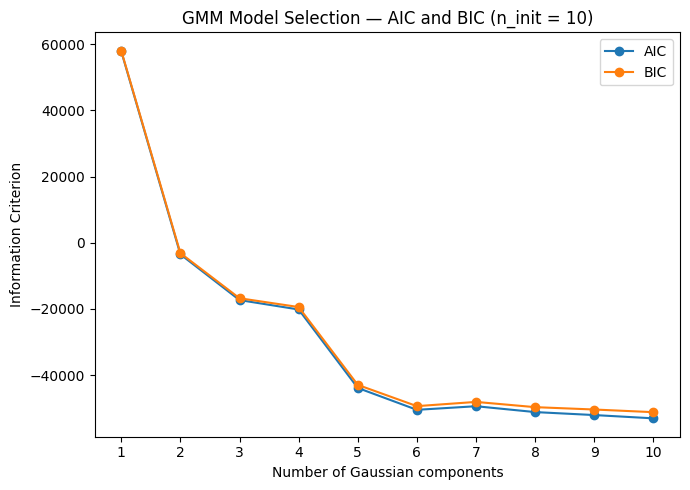

In [36]:
plt.figure(figsize=(7, 5))

plt.plot(
    gmm_results_10_init["n_components"],
    gmm_results_10_init["AIC"],
    marker="o",
    label="AIC"
)

plt.plot(
    gmm_results_10_init["n_components"],
    gmm_results_10_init["BIC"],
    marker="o",
    label="BIC"
)

plt.xlabel("Number of Gaussian components")
plt.ylabel("Information Criterion")
plt.title("GMM Model Selection — AIC and BIC (n_init = 10)")
plt.xticks(gmm_results_10_init["n_components"])
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
print(
    "Best n_components by AIC:",
    gmm_results_10_init.loc[
        gmm_results_10_init["AIC"].idxmin(),
        "n_components",
    ],
)

print(
    "Best n_components by BIC:",
    gmm_results_10_init.loc[
        gmm_results_10_init["BIC"].idxmin(),
        "n_components",
    ],
)

Best n_components by AIC: 10
Best n_components by BIC: 10


In [38]:
gmm_candidates = [5, 6, 10]

gmm_models = {}
gmm_candidate_summary = []
gmm_profiles = {}

for k in gmm_candidates:

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=RANDOM_STATE,
        n_init=10
    )

    gmm.fit(X_transformed)

    labels = gmm.predict(X_transformed)
    probabilities = gmm.predict_proba(X_transformed)
    max_probability = probabilities.max(axis=1)

    gmm_models[k] = gmm

    # -------------------------
    # Component sizes
    # -------------------------

    component_sizes = pd.Series(labels).value_counts()

    # -------------------------
    # Soft-assignment summary
    # -------------------------

    gmm_candidate_summary.append({
        "n_components": k,
        "AIC": gmm.aic(X_transformed),
        "BIC": gmm.bic(X_transformed),
        "smallest_component": component_sizes.min(),
        "largest_component": component_sizes.max(),
        "median_component_size": component_sizes.median(),
        "mean_max_probability": max_probability.mean(),
        "median_max_probability": np.median(max_probability),
        "pct_prob_below_0.60": 100 * (max_probability < 0.60).mean(),
        "pct_prob_below_0.80": 100 * (max_probability < 0.80).mean(),
    })

    # -------------------------
    # Profiles in original scale
    # -------------------------

    labeled = customer_features.copy()
    labeled["GMMCluster"] = labels

    profile = (
        labeled
        .groupby("GMMCluster")[clustering_features]
        .agg(["median", "mean"])
    )

    gmm_profiles[k] = profile


gmm_candidate_summary = pd.DataFrame(gmm_candidate_summary)

display(gmm_candidate_summary)

,n_components,AIC,BIC,smallest_component,largest_component,median_component_size,mean_max_probability,median_max_probability,pct_prob_below_0.60,pct_prob_below_0.80
0,5,-43892.088751,-42963.711664,664,1623,1123.0,0.991791,1.00000,0.204151,2.075536
1,6,-50506.563321,-49391.175023,483,1623,914.0,0.991222,1.00000,1.037768,1.531133
2,10,-53079.984740,-51216.551595,160,1077,494.0,0.957524,0.99495,1.905410,6.975162


Although the information criteria continue to improve toward the upper end of the evaluated range, a six-component model offers a more parsimonious compromise between fit, component size, assignment certainty, and interpretability. The ten-component solution is retained as a statistical-fit reference rather than treated as the operational segmentation.

In [39]:
# =========================
# Selected GMM
# =========================

gmm_selected = GaussianMixture(
    n_components=6,
    covariance_type="full",
    random_state=RANDOM_STATE,
    n_init=10
)

gmm_selected.fit(X_transformed)


# Hard assignments
gmm_labels = gmm_selected.predict(
    X_transformed
)


# Soft assignments
gmm_probabilities = gmm_selected.predict_proba(
    X_transformed
)


# Highest membership probability for each customer
max_membership_probability = (
    gmm_probabilities.max(axis=1)
)


# =========================
# Customer-level assignment table
# =========================

gmm_assignments = customer_features.copy()

gmm_assignments["GMMCluster"] = gmm_labels
gmm_assignments["MaxMembershipProbability"] = (
    max_membership_probability
)


# Add individual component probabilities
for k in range(gmm_selected.n_components):
    gmm_assignments[f"P_Component_{k}"] = (
        gmm_probabilities[:, k]
    )


# =========================
# Inspect ambiguous customers
# =========================

ambiguous_customers = (
    gmm_assignments
    .sort_values("MaxMembershipProbability")
)

display(
    ambiguous_customers.head(20)
)

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueProducts,TotalItems,AverageItemsPerInvoice,ActiveDays,CustomerTenureDays,GMMCluster,MaxMembershipProbability,P_Component_0,P_Component_1,P_Component_2,P_Component_3,P_Component_4,P_Component_5
CustomerID,,,,,,,,,,,,,,,,,
12727,11,10,5679.53,567.953000,132,2832,283.200000,9,655,5,0.500128,0.0,0.499872,0.0,0.0,0.0,0.500128
14307,89,10,5071.03,507.103000,205,3374,337.400000,9,732,1,0.503384,0.0,0.503384,0.0,0.0,0.0,0.496616
17802,82,10,5053.12,505.312000,283,2786,278.600000,9,726,1,0.503829,0.0,0.503829,0.0,0.0,0.0,0.496171
16003,30,10,5613.83,561.383000,146,2210,221.000000,8,736,5,0.508108,0.0,0.491892,0.0,0.0,0.0,0.508108
13059,250,10,2303.17,230.317000,155,864,86.400000,9,619,5,0.508138,0.0,0.491862,0.0,0.0,0.0,0.508138
15410,84,10,4685.72,468.572000,80,1902,190.200000,10,600,1,0.508661,0.0,0.508661,0.0,0.0,0.0,0.491339
15819,49,10,3934.79,393.479000,182,2928,292.800000,8,632,5,0.512055,0.0,0.487945,0.0,0.0,0.0,0.512055
15569,104,10,3586.35,358.635000,123,1736,173.600000,9,650,5,0.512075,0.0,0.487925,0.0,0.0,0.0,0.512075
17652,25,12,4867.72,405.643333,118,2509,209.083333,12,281,1,0.513084,0.0,0.513084,0.0,0.0,0.0,0.486916


In [40]:
gmm_profile = (
    gmm_assignments
    .groupby("GMMCluster")[clustering_features]
    .agg(["mean", "median"])
)

display(gmm_profile.loc[[1, 5]])

Recency         Frequency        MonetaryValue            \
                  mean median       mean median          mean    median   
GMMCluster                                                                
1            47.076923   18.0  23.544118   16.0  13213.217985  6333.435   
5           103.235156   50.5   6.813281    6.0   2526.756620  1971.030   

           AverageOrderValue             UniqueProducts         \
                        mean      median           mean median   
GMMCluster                                                       
1                 476.872685  358.735417     229.398190  182.5   
5                 371.343332  299.227143     107.689844   88.0   

           CustomerTenureDays         
                         mean median  
GMMCluster                            
1                  661.455882  717.5  
5                  552.109375  613.0

In [41]:
pd.Series(gmm_labels).value_counts().sort_index()

0    1623
1     884
2     944
3     664
4     483
5    1280
Name: count, dtype: int64

The GMM solution provides a more granular progression of customer activity than K-Means and, importantly, exposes uncertainty through membership probabilities. Customers with lower maximum membership probabilities represent transitional profiles rather than automatically being treated as anomalies.

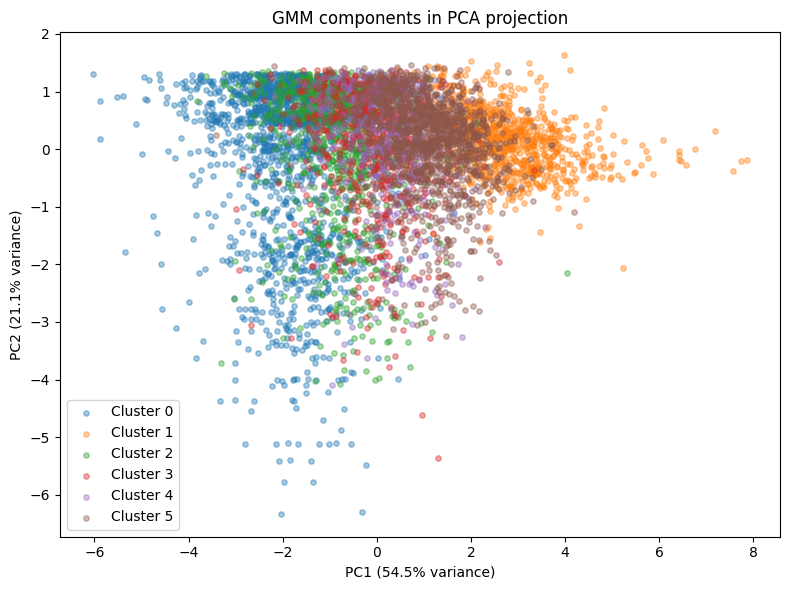

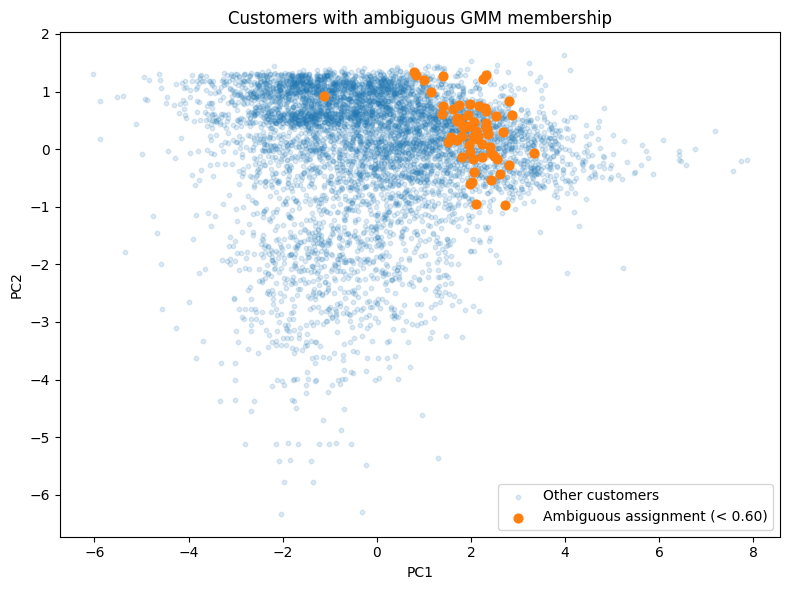

In [42]:
X_pca_labeled_gmm = X_pca.copy().assign(labels=gmm_labels)

labels_over_pc2_plot(
    X_pca_labeled_gmm,
    title="GMM components in PCA projection",
)

ambiguous_mask = max_membership_probability < 0.60

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    alpha=0.15,
    s=10,
    label="Other customers",
)
plt.scatter(
    X_pca.loc[ambiguous_mask, "PC1"],
    X_pca.loc[ambiguous_mask, "PC2"],
    s=40,
    label="Ambiguous assignment (< 0.60)",
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Customers with ambiguous GMM membership")
plt.tight_layout()
plt.show()

## 14. K-Means vs. GMM

In [43]:
kmeans_gmm_ari = adjusted_rand_score(
    k_mean_labels,
    gmm_labels,
)

print("Adjusted Rand Index:", kmeans_gmm_ari)

X_customer_labeled_gmm = X_customer.copy().assign(
    labels=gmm_labels
)
X_customer_labeled_kmeans = X_customer.copy().assign(
    labels=k_mean_labels
)

print("\nGMM profiles")
display(cluster_summary(X_customer_labeled_gmm))

print("\nK-Means profiles")
display(cluster_summary(X_customer_labeled_kmeans))

Adjusted Rand Index: 0.22520620600748417

GMM profiles


cluster_size labels     Recency         Frequency        MonetaryValue  \
         count               mean median       mean median          mean   
0         1623      0  355.160197  388.0   1.000000    1.0    350.076298   
1          884      1   47.076923   18.0  23.544118   16.0  13213.217985   
2          944      2  245.165254  211.0   2.000000    2.0    871.862037   
3          664      3  181.105422  100.5   3.000000    3.0   1204.154006   
4          483      4  168.855072   91.0   4.000000    4.0   1320.758077   
5         1280      5  103.235156   50.5   6.813281    6.0   2526.756620   

            AverageOrderValue             UniqueProducts         \
     median              mean      median           mean median   
0   232.480        350.076298  232.480000      20.802218   16.0   
1  6333.435        476.872685  358.735417     229.398190  182.5   
2   530.565        435.931019  265.282500      37.693856   30.5   
3   842.830        401.384669  280.943333      57.441265   46.0   
4  1091.700        330.189519  272.925000      70.010352   57.0   
5  1971.030        371.343332  299.227143     107.689844   88.0   

  CustomerTenureDays         
                mean median  
0         355.160197  388.0  
1         661.455882  717.5  
2         411.277542  431.5  
3         446.403614  467.5  
4         492.432712  549.0  
5         552.109375  613.0


K-Means profiles


cluster_size labels     Recency         Frequency        MonetaryValue  \
         count               mean median       mean median          mean   
0         2708      0  360.411374  381.0   2.187223    2.0    553.975891   
1         2343      1   74.180111   31.0  12.568075    8.0   6705.059455   
2          827      2   40.666264   30.0   1.933495    1.0    644.870811   

            AverageOrderValue             UniqueProducts         \
     median              mean      median           mean median   
0   414.165        279.635136  218.184167      29.685377   23.0   
1  2927.380        535.207492  358.942000     158.454972  120.0   
2   430.150        352.267818  265.140000      36.619105   26.0   

  CustomerTenureDays         
                mean median  
0         501.159897  514.5  
1         584.351686  642.0  
2          77.482467   65.0

The two methods produce materially different partitions because they encode different geometric assumptions. K-Means yields broader, operationally simpler segments, while the GMM describes finer levels of customer activity and can represent uncertain boundaries through soft assignments.

For this project, K-Means is retained as the primary business segmentation and GMM as a complementary probabilistic view.

## 15. Post-hoc geographic profiling

Country is not used to construct the clusters. It is introduced only after segmentation to test whether the behavioral groups have different geographic compositions.

In [44]:
# =========================
# Join features + KMeans label + PrimaryCountry
# =========================

customer_cluster_country = customer_features.copy()

customer_cluster_country["Cluster"] = k_mean_labels

customer_cluster_country = customer_cluster_country.join(
    customer_metadata[["PrimaryCountry"]]
)

display(customer_cluster_country.head())

print(
    "Missing PrimaryCountry:",
    customer_cluster_country["PrimaryCountry"].isna().sum()
)

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueProducts,TotalItems,AverageItemsPerInvoice,ActiveDays,CustomerTenureDays,Cluster,PrimaryCountry
CustomerID,,,,,,,,,,,
12346,326,12,77556.46,6463.038333,27,74285,6190.416667,8,726,1,United Kingdom
12347,2,8,5633.32,704.165000,126,3286,410.750000,8,404,1,Iceland
12348,75,5,2019.40,403.880000,25,2714,542.800000,5,438,1,Finland
12349,19,4,4428.69,1107.172500,138,1624,406.000000,4,589,1,Italy
12350,310,1,334.40,334.400000,17,197,197.000000,1,310,0,Norway


Missing PrimaryCountry: 0


In [45]:
country_counts = pd.crosstab(
    customer_cluster_country["Cluster"],
    customer_cluster_country["PrimaryCountry"]
)

country_proportions = pd.crosstab(
    customer_cluster_country["Cluster"],
    customer_cluster_country["PrimaryCountry"],
    normalize="index"
)

display(country_counts)
display((country_proportions * 100).round(2))

PrimaryCountry,Australia,Austria,Bahrain,Belgium,Brazil,Canada,Channel Islands,Cyprus,Czech Republic,Denmark,...,Singapore,Spain,Sweden,Switzerland,Thailand,USA,United Arab Emirates,United Kingdom,Unspecified,West Indies
Cluster,,,,,,,,,,,,,,,,,,,,,
0,9,5,2,9,2,3,4,5,1,2,...,0,19,10,4,0,5,2,2508,3,1
1,5,6,0,14,0,1,8,3,0,6,...,1,13,6,14,1,1,2,2111,2,0
2,0,1,0,5,0,1,1,1,0,1,...,0,6,3,4,0,3,0,731,1,0


PrimaryCountry,Australia,Austria,Bahrain,Belgium,Brazil,Canada,Channel Islands,Cyprus,Czech Republic,Denmark,...,Singapore,Spain,Sweden,Switzerland,Thailand,USA,United Arab Emirates,United Kingdom,Unspecified,West Indies
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.33,0.18,0.07,0.33,0.07,0.11,0.15,0.18,0.04,0.07,...,0.00,0.70,0.37,0.15,0.00,0.18,0.07,92.61,0.11,0.04
1,0.21,0.26,0.00,0.60,0.00,0.04,0.34,0.13,0.00,0.26,...,0.04,0.55,0.26,0.60,0.04,0.04,0.09,90.10,0.09,0.00
2,0.00,0.12,0.00,0.60,0.00,0.12,0.12,0.12,0.00,0.12,...,0.00,0.73,0.36,0.48,0.00,0.36,0.00,88.39,0.12,0.00


All three segments are dominated by United Kingdom customers, although the relative international share varies modestly across clusters. These differences are descriptive and should not be interpreted causally.

## 16. Anomaly detection

Isolation Forest is used to identify unusual customer behavior in the transformed feature space. A 2% contamination setting is used as a practical inspection threshold rather than as an estimate of the true anomaly rate.

In [46]:
isolation_forest = IsolationForest(
    contamination=0.02,
    random_state=RANDOM_STATE
)

anomaly_label = isolation_forest.fit_predict(X_transformed)

# Lower score_samples values are more anomalous.
# Reverse the sign so larger values mean more anomalous.
anomaly_score = -isolation_forest.score_samples(X_transformed)

In [47]:
print("Anomalies:", (anomaly_label == -1).sum())
print(
    "Percentage:",
    100 * (anomaly_label == -1).mean()
)

Anomalies: 118
Percentage: 2.0074855392990814


In [48]:
anomaly_results = customer_features.copy()

anomaly_results["AnomalyLabel"] = anomaly_label
anomaly_results["AnomalyScore"] = anomaly_score

In [49]:
extreme_customers = (
    anomaly_results
    .sort_values("AnomalyScore", ascending=False)
)

display(extreme_customers.head(20))

,Recency,Frequency,MonetaryValue,AverageOrderValue,UniqueProducts,TotalItems,AverageItemsPerInvoice,ActiveDays,CustomerTenureDays,AnomalyLabel,AnomalyScore
CustomerID,,,,,,,,,,,
18102,1,145,608821.65,4198.770000,382,188340,1298.896552,67,739,-1,0.713013
14646,2,151,528602.52,3500.678940,961,367193,2431.741722,91,737,-1,0.709114
15195,3,1,3861.00,3861.000000,1,1404,1404.000000,1,3,-1,0.707175
14096,4,17,65164.79,3833.222941,1119,16352,961.882353,17,102,-1,0.700874
14911,1,398,295972.63,743.649824,2550,149987,376.851759,255,739,-1,0.692079
17511,3,60,175603.55,2926.725833,657,119656,1994.266667,51,738,-1,0.688385
16000,3,3,12393.70,4131.233333,9,5110,1703.333333,1,3,-1,0.686764
14156,10,156,313946.37,2012.476731,1446,165992,1064.051282,121,739,-1,0.686723
16446,1,2,168472.50,84236.250000,3,80997,40498.500000,2,206,-1,0.686262


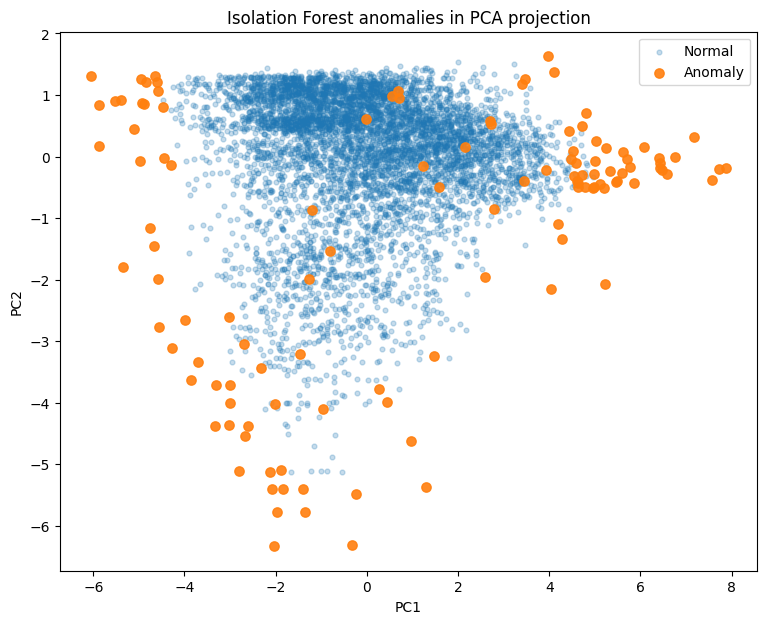

In [50]:
X_pca_anomaly = X_pca.copy()

X_pca_anomaly["AnomalyLabel"] = anomaly_label
X_pca_anomaly["AnomalyScore"] = anomaly_score

normal_mask = X_pca_anomaly["AnomalyLabel"] == 1
anomaly_mask = X_pca_anomaly["AnomalyLabel"] == -1

plt.figure(figsize=(9, 7))

plt.scatter(
    X_pca_anomaly.loc[normal_mask, "PC1"],
    X_pca_anomaly.loc[normal_mask, "PC2"],
    s=12,
    alpha=0.25,
    label="Normal"
)

plt.scatter(
    X_pca_anomaly.loc[anomaly_mask, "PC1"],
    X_pca_anomaly.loc[anomaly_mask, "PC2"],
    s=45,
    alpha=0.9,
    label="Anomaly"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest anomalies in PCA projection")
plt.legend()
plt.show()

The most extreme observations include several distinct behaviors: exceptionally frequent and high-value customers, customers with very large average orders, and unusually low-activity profiles.

These observations are not automatically removed. Statistical rarity can correspond to legitimate and commercially important customer behavior, especially in a dataset that includes wholesale buyers.

## 17. Conclusions

- The raw transaction table must first be converted from invoice-line grain to customer grain before segmentation is meaningful.
- Positive purchase activity is used to build behavioral features, while cancellation and country information are retained separately for interpretation.
- Customer behavior is highly skewed, making `log1p` transformation and standardization important before distance-based clustering.
- A compact six-feature representation is used to limit redundancy while preserving recency, frequency, value, basket size, product diversity, and observed tenure.
- K-Means with three clusters provides the clearest operational segmentation among the alternatives studied.
- Multiple initializations materially improve K-Means stability and are used consistently in the final workflow.
- DBSCAN primarily finds one large connected density region plus small isolated structures, making it less useful for broad customer segmentation here.
- A six-component GMM provides a complementary probabilistic view with soft membership assignments.
- Isolation Forest highlights multivariate behavioral extremes, but these customers are treated as cases for inspection rather than automatic removal.